# Notebook 12 — Disjoint-range replication test (post-B run)

**Goal.** Out-of-sample validation of $M_1^{\star}$ on data unseen during fit:

- **Train** on $N \le 10^{13}$ (pre-extension dataset, $n = 140$).
- **Test** on $N \in \{3 \cdot 10^{13}, 10^{14}, 3 \cdot 10^{14}\}$ (B-extension, generated by `run_extension/launch.sh`).

Report:
1. Train-only $M_1^{\star}$ coefficients $(a, b)$.
2. Out-of-sample weighted $R^2$ on test set.
3. Per-test-point residual.
4. Whether full-dataset coefs lie in train-only 95% bootstrap CI.

Paper §4.5 calls this *“the cleanest fix”* for the asymptotic-regime concern.

**Scaffolding behaviour.** Before B run completes (no test CSV in `ml_data/`), the test section reports "test set empty" and skips. After `post_launch.sh`, full output is produced.

Writes `outputs/results/disjoint_replication.json`.

In [1]:
import math, json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import integrate
import matplotlib.pyplot as plt

WORK = Path.cwd()
DATA_DIR = WORK / 'ml_data'
OUT_DIR = WORK / 'outputs' / 'results'
OUT_DIR.mkdir(parents=True, exist_ok=True)
C2_TWIN = 0.6601618158468695739278121100145557784326233602847334133194484233354

# Train / test split — train is everything <= TRAIN_N_MAX, test is everything above.
TRAIN_N_MAX = 10**13
RHO_MIN, RHO_MAX = 0.05, 1.10

def hl_correct(g):
    if g <= 0 or g % 2: return 0.0
    n = g
    while n % 2 == 0: n //= 2
    corr = 1.0
    p = 3
    while p * p <= n:
        if n % p == 0:
            corr *= (p - 1) / (p - 2)
            while n % p == 0: n //= p
        p += 2
    if n > 1: corr *= (n - 1) / (n - 2)
    return 2 * C2_TWIN * corr

def li2(N):
    val, _ = integrate.quad(lambda t: 1.0 / np.log(t)**2, 2.0, N)
    return val

def omega(g):
    if g <= 1: return 0
    n, count = g, 0
    p = 2
    while p*p <= n:
        if n % p == 0:
            count += 1
            while n % p == 0: n //= p
        p += 1
    if n > 1: count += 1
    return count

print(f'Train: N <= {TRAIN_N_MAX:.0e}')
print(f'Test:  N >  {TRAIN_N_MAX:.0e}')
print(f'Filter: rho in [{RHO_MIN}, {RHO_MAX}], g in [2, 100], N_g >= 100')

Train: N <= 1e+13
Test:  N >  1e+13
Filter: rho in [0.05, 1.1], g in [2, 100], N_g >= 100


In [2]:
# Load all histograms via auto-discovery.
cached = sorted(DATA_DIR.glob('gaps_N*.csv'))
histograms = {int(f.stem.replace('gaps_N','')): pd.read_csv(f) for f in cached}
print(f'Loaded {len(histograms)} histograms')
for N in sorted(histograms.keys()):
    split = 'train' if N <= TRAIN_N_MAX else 'test'
    print(f'  N = {N:>16d}  ({split})  rows = {len(histograms[N])}')

Loaded 28 histograms
  N =           100000  (train)  rows = 34
  N =           196841  (train)  rows = 39
  N =           387467  (train)  rows = 43
  N =           762698  (train)  rows = 51
  N =          1501310  (train)  rows = 59
  N =          2955209  (train)  rows = 63
  N =          5817091  (train)  rows = 68
  N =         11450475  (train)  rows = 76
  N =         22539339  (train)  rows = 82
  N =         44366873  (train)  rows = 90
  N =         87332616  (train)  rows = 97
  N =        171907220  (train)  rows = 105
  N =        338385515  (train)  rows = 114
  N =        666084629  (train)  rows = 126
  N =       1311133937  (train)  rows = 133
  N =       2580861540  (train)  rows = 147
  N =       5080218046  (train)  rows = 155
  N =      10000000000  (train)  rows = 167
  N =      30000000000  (train)  rows = 189
  N =      70000000000  (train)  rows = 206
  N =     100000000000  (train)  rows = 209
  N =     300000000000  (train)  rows = 231
  N =    1000000000000

In [3]:
# Build the filtered dataset with both train and test points.
rows = []
for N, df in histograms.items():
    lnN, lnlnN = math.log(N), math.log(math.log(N))
    li2_N = li2(N)
    for _, r in df.iterrows():
        g, emp = int(r['gap']), int(r['count'])
        if g < 2 or g > 100 or g % 2 or emp < 100: continue
        Cg = hl_correct(g)
        rho = g * Cg / lnN
        if not (RHO_MIN <= rho <= RHO_MAX): continue
        rows.append({
            'N': N, 'g': g, 'omega': omega(g),
            'rho': rho, 'lnlnN': lnlnN,
            'sqrt_omega_g': math.sqrt(omega(g)),
            'log_C_li': math.log(Cg * li2_N),
            'log_empir': math.log(emp),
            'weight': min(1.0, emp / 1000.0),
            'split': 'train' if N <= TRAIN_N_MAX else 'test',
        })

D = pd.DataFrame(rows)
D_train = D[D['split'] == 'train'].reset_index(drop=True)
D_test  = D[D['split'] == 'test'].reset_index(drop=True)

print(f'Train set: n = {len(D_train)}  (over {D_train["N"].nunique()} N values)')
print(f'Test set:  n = {len(D_test)}   (over {D_test["N"].nunique()} N values)')
if len(D_test):
    print(f'  test N values: {sorted(D_test["N"].unique())}')

Train set: n = 140  (over 25 N values)
Test set:  n = 29   (over 3 N values)
  test N values: [np.int64(30000000000000), np.int64(100000000000000), np.int64(300000000000000)]


In [4]:
# Fit M1* (no intercept, weighted LS) on train set.
def fit_M1_star(d):
    w = d['weight'].values
    sqw = np.sqrt(w)
    y_target = d['log_empir'].values - (d['log_C_li'].values - d['rho'].values)
    X = np.column_stack([d['sqrt_omega_g'].values, d['lnlnN'].values])
    coef, *_ = np.linalg.lstsq(X * sqw[:, None], y_target * sqw, rcond=None)
    return coef  # (a, b)

def predict_M1_star(d, coef):
    a, b = coef
    return d['log_C_li'].values - d['rho'].values + a * d['sqrt_omega_g'].values + b * d['lnlnN'].values

def weighted_r2(y, yhat, w):
    resid = y - yhat
    ss_res = float(np.sum(w * resid**2))
    ss_tot = float(np.sum(w * (y - np.average(y, weights=w))**2))
    return 1.0 - ss_res / ss_tot

coef_train = fit_M1_star(D_train)
coef_full  = fit_M1_star(D) if len(D_test) else coef_train

y_train = D_train['log_empir'].values
yhat_train = predict_M1_star(D_train, coef_train)
r2_train = weighted_r2(y_train, yhat_train, D_train['weight'].values)

print('=== M1* train fit (N <= 1e13) ===')
print(f'  a (sqrt(omega))  = {coef_train[0]:+.4f}')
print(f'  b (log log N)    = {coef_train[1]:+.4f}')
print(f'  in-sample R^2    = {r2_train:.4f}')
print()
print('=== M1* full fit (all data) ===')
print(f'  a (sqrt(omega))  = {coef_full[0]:+.4f}')
print(f'  b (log log N)    = {coef_full[1]:+.4f}')

=== M1* train fit (N <= 1e13) ===
  a (sqrt(omega))  = +0.8552
  b (log log N)    = -0.2017
  in-sample R^2    = 0.9996

=== M1* full fit (all data) ===
  a (sqrt(omega))  = +0.8361
  b (log log N)    = -0.1949


In [5]:
# Out-of-sample evaluation on test set (if any).
if len(D_test) == 0:
    print('Test set is empty.')
    print('Run B (`bash run_extension/start.sh`) to generate test data,')
    print('then `bash run_extension/post_launch.sh` and re-execute this notebook.')
    out_of_sample_metrics = None
else:
    y_test = D_test['log_empir'].values
    yhat_test = predict_M1_star(D_test, coef_train)
    w_test = D_test['weight'].values
    r2_test = weighted_r2(y_test, yhat_test, w_test)
    resid = y_test - yhat_test
    print('=== Out-of-sample evaluation ===')
    print(f'  test n            = {len(D_test)}')
    print(f'  weighted R^2      = {r2_test:.4f}')
    print(f'  mean residual     = {float(np.average(resid, weights=w_test)):+.4f}')
    print(f'  RMS residual      = {float(np.sqrt(np.average(resid**2, weights=w_test))):.4f}')
    print()
    print('Per-test-N breakdown:')
    for N in sorted(D_test['N'].unique()):
        sub = D_test[D_test['N'] == N]
        sub_y = sub['log_empir'].values
        sub_yhat = predict_M1_star(sub, coef_train)
        sub_w = sub['weight'].values
        sub_r2 = weighted_r2(sub_y, sub_yhat, sub_w) if len(sub) > 1 else float('nan')
        print(f'  N = {N:>16d}: n = {len(sub)}, R^2 = {sub_r2:.4f}')
    out_of_sample_metrics = {
        'n_test': len(D_test),
        'weighted_r2': float(r2_test),
        'mean_residual': float(np.average(resid, weights=w_test)),
        'rms_residual': float(np.sqrt(np.average(resid**2, weights=w_test))),
    }

=== Out-of-sample evaluation ===
  test n            = 29
  weighted R^2      = 0.9863
  mean residual     = -0.0052
  RMS residual      = 0.1081

Per-test-N breakdown:
  N =   30000000000000: n = 9, R^2 = 0.8798
  N =  100000000000000: n = 10, R^2 = 0.8883
  N =  300000000000000: n = 10, R^2 = 0.8891


In [6]:
# Train-only bootstrap 95% CI (200 resamples — fast, sufficient).
B = 200
rng = np.random.default_rng(42)
boot = np.empty((B, 2))
for b in range(B):
    idx = rng.integers(0, len(D_train), size=len(D_train))
    boot[b] = fit_M1_star(D_train.iloc[idx])
ci_a = (float(np.percentile(boot[:, 0], 2.5)), float(np.percentile(boot[:, 0], 97.5)))
ci_b = (float(np.percentile(boot[:, 1], 2.5)), float(np.percentile(boot[:, 1], 97.5)))

print('=== Train-only 95% bootstrap CI ===')
print(f'  a (sqrt(omega))  in [{ci_a[0]:+.4f}, {ci_a[1]:+.4f}]')
print(f'  b (log log N)    in [{ci_b[0]:+.4f}, {ci_b[1]:+.4f}]')
if len(D_test):
    a_in_ci = ci_a[0] <= coef_full[0] <= ci_a[1]
    b_in_ci = ci_b[0] <= coef_full[1] <= ci_b[1]
    print()
    print(f'Full-dataset a = {coef_full[0]:+.4f}: '
          f'in train-only 95% CI? {a_in_ci}')
    print(f'Full-dataset b = {coef_full[1]:+.4f}: '
          f'in train-only 95% CI? {b_in_ci}')

=== Train-only 95% bootstrap CI ===
  a (sqrt(omega))  in [+0.7617, +0.9275]
  b (log log N)    in [-0.2283, -0.1656]

Full-dataset a = +0.8361: in train-only 95% CI? True
Full-dataset b = -0.1949: in train-only 95% CI? True


Saved fig_disjoint_replication.png


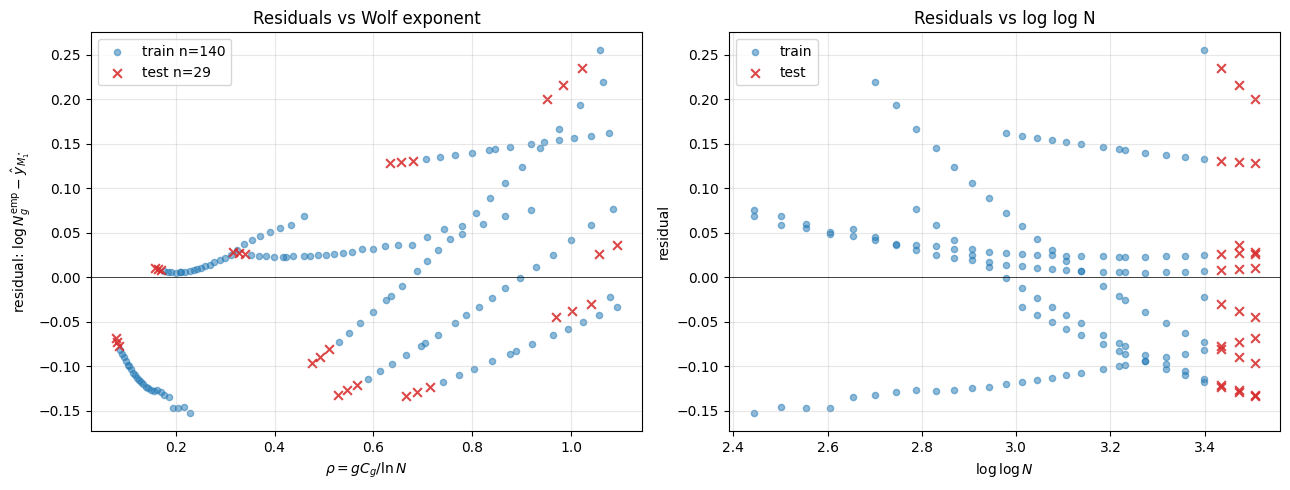

In [7]:
# Diagnostic plots.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(D_train['rho'], D_train['log_empir'] - predict_M1_star(D_train, coef_train),
           s=20, alpha=0.5, label=f'train n={len(D_train)}', color='C0')
if len(D_test):
    ax.scatter(D_test['rho'], D_test['log_empir'] - predict_M1_star(D_test, coef_train),
               s=40, alpha=0.85, label=f'test n={len(D_test)}', color='C3', marker='x')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel(r'$\rho = g C_g / \ln N$')
ax.set_ylabel(r'residual: $\log N_g^{\mathrm{emp}} - \hat y_{M_1^\star}$')
ax.set_title('Residuals vs Wolf exponent')
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
ax.scatter(D_train['lnlnN'], D_train['log_empir'] - predict_M1_star(D_train, coef_train),
           s=20, alpha=0.5, label=f'train', color='C0')
if len(D_test):
    ax.scatter(D_test['lnlnN'], D_test['log_empir'] - predict_M1_star(D_test, coef_train),
               s=40, alpha=0.85, label=f'test', color='C3', marker='x')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel(r'$\log \log N$')
ax.set_ylabel(r'residual')
ax.set_title('Residuals vs log log N')
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(WORK / 'outputs' / 'figures' / 'fig_disjoint_replication.png',
            dpi=120, bbox_inches='tight')
print('Saved fig_disjoint_replication.png')

In [8]:
# Save summary JSON.
summary = {
    'train_N_max': TRAIN_N_MAX,
    'filter': {'rho_min': RHO_MIN, 'rho_max': RHO_MAX,
               'g_range': [2, 100], 'emp_min': 100},
    'train': {
        'n': len(D_train),
        'N_values': sorted([int(N) for N in D_train['N'].unique()]),
        'coefs': {'a': float(coef_train[0]), 'b': float(coef_train[1])},
        'in_sample_r2': float(r2_train),
        'bootstrap_95ci': {'a': list(ci_a), 'b': list(ci_b)},
    },
    'full': {
        'n': len(D),
        'coefs': {'a': float(coef_full[0]), 'b': float(coef_full[1])},
    },
    'test': out_of_sample_metrics if len(D_test) else None,
}
(OUT_DIR / 'disjoint_replication.json').write_text(json.dumps(summary, indent=2))
print('Saved:', OUT_DIR / 'disjoint_replication.json')

Saved: /home/krse/notebooks/ver-02/outputs/results/disjoint_replication.json
